In [113]:
print("all okay")

all okay


In [114]:
from dotenv import load_dotenv
import os
load_dotenv()

True

In [115]:
# print("")

In [116]:
from langchain_openai import ChatOpenAI

In [117]:
# from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_groq import ChatGroq

In [118]:
chat_llm = ChatGroq(model = "llama-3.3-70b-versatile")

In [119]:
chat_llm.invoke("Hello, how are you?").content

"Hello, I'm doing well, thank you for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm always happy to chat and help with any questions or topics you'd like to discuss. How about you? How's your day going so far?"

In [120]:
from typing_extensions import TypedDict, Annotated
import operator
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage

In [121]:
class GraphState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

In [122]:
{
    "messages": [HumanMessage(content="Hi, this is Anees. Say Hello in detail.")]
}

{'messages': [HumanMessage(content='Hi, this is Anees. Say Hello in detail.', additional_kwargs={}, response_metadata={})]}

In [123]:
["Hye"]

['Hye']

In [124]:
["Hye", "How are you?"]

['Hye', 'How are you?']

In [125]:
def llm_call(state: GraphState) -> dict:
    """Call the LLM using conversation messages and append AI responses."""
    response = chat_llm.invoke(state["messages"]) # AI message
    return {
        "messages": [response]
    }


In [126]:
def token_counter(state: GraphState) -> dict:
    """count tokens (simple word count) in the last AI message"""
    last_msg = state["messages"][-1]
    text = last_msg.content
    token_number = len(text.split())
    summary = f"Total token number in the generated answer (word count) is {token_number}"
    return {
        "messages": [AIMessage(content=summary)]
    }

In [127]:
from langgraph.graph import StateGraph

In [128]:
builder = StateGraph(GraphState)

In [129]:
builder.add_node("llm_call", llm_call)
builder.add_node("token_counter", token_counter)

In [130]:
builder.set_entry_point("llm_call")
builder.add_edge("llm_call", "token_counter")
builder.set_finish_point("token_counter")

In [131]:
app = builder.compile()

In [132]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

In [133]:
from IPython.display import Image, display

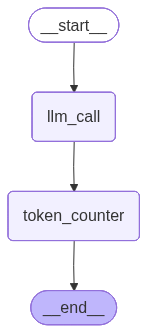

In [134]:
display(Image(app.get_graph().draw_mermaid_png()))

In [135]:
result = app.invoke({
    "messages": [HumanMessage(content="Hi, this is Anees. Say Hello in detail.")]
})

In [136]:
result

{'messages': [HumanMessage(content='Hi, this is Anees. Say Hello in detail.', additional_kwargs={}, response_metadata={}),
  AIMessage(content="Hello Anees, it's a pleasure to meet you. I hope this greeting finds you in the best of spirits and with a heart full of joy. As we begin our conversation, I want to take a moment to appreciate the opportunity to connect with you and explore the vast array of topics and ideas that we can discuss.\n\nHello is more than just a simple greeting; it's an invitation to start a new conversation, to learn from each other, and to share our thoughts and experiences. It's a chance to break the ice, to build a connection, and to create a foundation for a meaningful exchange of ideas.\n\nAs we say hello, I want to acknowledge the unique individual that you are, with your own distinct perspective, interests, and passions. I'm excited to learn more about you, to hear your stories, and to discover the things that make you tick.\n\nSo, hello Anees, let's start 

In [137]:
for m in result["messages"]:
    print(type(m).__name__, ":", m.content)

HumanMessage : Hi, this is Anees. Say Hello in detail.
AIMessage : Hello Anees, it's a pleasure to meet you. I hope this greeting finds you in the best of spirits and with a heart full of joy. As we begin our conversation, I want to take a moment to appreciate the opportunity to connect with you and explore the vast array of topics and ideas that we can discuss.

Hello is more than just a simple greeting; it's an invitation to start a new conversation, to learn from each other, and to share our thoughts and experiences. It's a chance to break the ice, to build a connection, and to create a foundation for a meaningful exchange of ideas.

As we say hello, I want to acknowledge the unique individual that you are, with your own distinct perspective, interests, and passions. I'm excited to learn more about you, to hear your stories, and to discover the things that make you tick.

So, hello Anees, let's start this conversation with an open mind, a willingness to listen, and a desire to learn

In [138]:
chat_llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000022D44DE8690>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000022D44E69610>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [139]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [140]:
api_wrapper = WikipediaAPIWrapper(top_k_results=5, doc_content_chars_max=500)

In [141]:
wiki_tool = WikipediaQueryRun(api_wrapper=api_wrapper)

In [142]:
wiki_tool.run({"query": "Generative AI"})

'Page: Generative artificial intelligence\nSummary: Generative artificial intelligence, also known as generative AI or GenAI, is a subfield of artificial intelligence that uses generative models to generate text, images, videos, audio, software code or other forms of data.\nThese models learn the underlying patterns and structures of their training data and use them to generate new data\nin response to input, which often takes the form of natural language prompts.\nThe generated material is often cal'

'Page: Generative artificial intelligence\nSummary: Generative artificial intelligence, also known as generative AI or GenAI, is a subfield of artificial intelligence that uses generative models to generate text, images, videos, audio, software code or other forms of data.\nThese models learn the underlying patterns and structures of their training data and use them to generate new data\nin response to input, which often takes the form of natural language prompts.\nThe generated material is often cal'

In [143]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")

In [144]:
print(TAVILY_API_KEY)

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


In [146]:
tool = TavilySearchResults(tavily_api_key = TAVILY_API_KEY)

In [147]:
tool.invoke({"query": "What is the latest news about generative AI?"})

[{'title': 'Generative AI recent news | AI Business',
  'url': 'https://aibusiness.com/generative-ai',
  'content': '### Latest News\n\nPic of ElevenLabs logo reflection\n\n### Trending articles\n\nPic of ElevenLabs logo reflection\n\nFeb 12, 2026\n\nIllustration of map of Europe\n\nFeb 11, 2026\n\nProcess Mining Matures in the Age of Generative AI\n\nHow AI is Reducing the Administrative Burden in Sales\n\nThe Shift Toward AI Data Quality as a Core Product\n\nVertical AI Systems and Open Source Flexibility\n\nData and computer\n\nSponsored by Google Cloud\n\n## Choosing Your First Generative AI Use Cases\n\nTo get started with generative AI, first focus on areas that can improve human experiences with information.\n\nAI Business logo\n\n##### Discover more\n\n##### Working with us\n\n##### Communicate\n\n##### Join Us\n\n##### Follow Us\n\nInforma [...] #### Related Topics\n\n#### Recent in Automation\n\nWaymo sensor dome\nDassault Systèmes and Nvidia partner. Image includes Lucid Mot

In [148]:
from langchain_community.tools import DuckDuckGoSearchRun
search = DuckDuckGoSearchRun()

In [149]:
search.invoke("What is the latest update on Iphone 17 release?")

"2 weeks ago - It was announced on June 5, 2023, at Apple's annual Worldwide Developers Conference alongside watchOS 10, iPadOS 17, tvOS 17 and macOS Sonoma. It was made publicly available on September 18, 2023 , as a free software update for supported iOS devices (see the supported devices section). 19 hours ago - New screening tools for calls and messages help eliminate distractions so users can focus on the conversations that matter most. iOS 26 also introduces new features in CarPlay, Apple Music, Maps, and Wallet, as well as Apple Games, a brand-new ... 19 hours ago - New screening tools for calls and messages help eliminate distractions so users can focus on the conversations that matter most. iOS 26 also introduces new features in CarPlay, Apple Music, Maps, and Wallet, as well as Apple Games, a brand-new ... October 9, 2025 - The iPhone 17e is rumoured to launch in the spring of 2026 . Read on for more detailed analysis of the new iPhone 17 colors, cameras, battery life, specs,

"2 weeks ago - It was announced on June 5, 2023, at Apple's annual Worldwide Developers Conference alongside watchOS 10, iPadOS 17, tvOS 17 and macOS Sonoma. It was made publicly available on September 18, 2023 , as a free software update for supported iOS devices (see the supported devices section). 19 hours ago - New screening tools for calls and messages help eliminate distractions so users can focus on the conversations that matter most. iOS 26 also introduces new features in CarPlay, Apple Music, Maps, and Wallet, as well as Apple Games, a brand-new ... 19 hours ago - New screening tools for calls and messages help eliminate distractions so users can focus on the conversations that matter most. iOS 26 also introduces new features in CarPlay, Apple Music, Maps, and Wallet, as well as Apple Games, a brand-new ... October 9, 2025 - The iPhone 17e is rumoured to launch in the spring of 2026 . Read on for more detailed analysis of the new iPhone 17 colors, cameras, battery life, specs, and features, plus the iPhone 17 release date and pricing. 5 days ago - ... In the iOS 26.4 update that's coming this spring, Apple will introduce a new version of Siri that's going to overhaul how we interact with the personal assistant and what it's able to do."

In [150]:
from langchain_community.tools import YouTubeSearchTool


In [151]:
tool = YouTubeSearchTool()

In [152]:
tool.name

'youtube_search'

In [153]:
tool.description

'search for youtube videos associated with a person. the input to this tool should be a comma separated list, the first part contains a person name and the second a number that is the maximum number of video results to return aka num_results. the second part is optional'

In [154]:
tool.run("langgraph tutorial")

"['https://www.youtube.com/watch?v=CnXdddeZ4tQ&pp=ygUSbGFuZ2dyYXBoIHR1dG9yaWFs', 'https://www.youtube.com/watch?v=jGg_1h0qzaM&pp=ygUSbGFuZ2dyYXBoIHR1dG9yaWFs']"

"['https://www.youtube.com/watch?v=CnXdddeZ4tQ&pp=ygUSbGFuZ2dyYXBoIHR1dG9yaWFs', 'https://www.youtube.com/watch?v=jGg_1h0qzaM&pp=ygUSbGFuZ2dyYXBoIHR1dG9yaWFs']"

In [155]:
def multiply(a:int, b:int) -> int:
    return a * b

In [156]:
multiply(10, 4)

40

In [158]:
from langchain.tools import tool

In [161]:
@tool
def multiply(a:int, b:int) -> int:
    """This tool is for the multiplication"""
    return a * b

In [162]:
multiply.invoke({"a": 10, "b": 4})

40

In [163]:
multiply.name

'multiply'

In [164]:
multiply.description

'This tool is for the multiplication'

In [165]:
multiply.args

{'a': {'title': 'A', 'type': 'integer'},
 'b': {'title': 'B', 'type': 'integer'}}

In [167]:
@tool
def get_word_length(word:str) -> int:
    """This is custom tool to count the length of the word"""
    return len(word)

In [169]:
get_word_length.invoke("hello world")

11

In [170]:
@tool
def call_gmail_api(args):
    """this is a tool to call gmail api"""
    pass

In [171]:
@tool
def call_sqlitedb(args):
    """this is a tool to call sqlite db"""
    pass

In [172]:
import yfinance as yf

In [173]:
@tool
def get_stock_price(ticker:str) -> str: 
    """this is a tool to get stock price using yfinance"""
    try:
        stock = yf.Ticker(ticker)

        # Get last 1 day historical data
        data = stock.history(period="1d")

        if data.empty:
            return f"No data found for ticker '{ticker}'. Please check the symbol."

        latest_close = data["Close"].iloc[-1]

        # Detect currency
        currency = stock.info.get("currency", "")
        symbol_map = {
            "INR": "₹",
            "USD": "$",
            "EUR": "€",
            "GBP": "£"
        }

        symbol = symbol_map.get(currency, "")
        currency_text = currency if currency else ""

        if symbol:
            return f"The last closing price of {ticker.upper()} was {symbol}{latest_close:.2f}."
        else:
            return f"The last closing price of {ticker.upper()} was {latest_close:.2f} {currency_text}."

    except Exception as e:
        return f"An error occurred while fetching stock data: {str(e)}"


In [174]:
get_stock_price.invoke("TCS.NS")

'The last closing price of TCS.NS was ₹2750.10.'

In [175]:
get_stock_price.invoke("AAPL")

'The last closing price of AAPL was $265.04.'

In [176]:
get_stock_price.invoke("TSLA")

'The last closing price of TSLA was $418.21.'

In [178]:
get_stock_price.invoke("HRL")

'The last closing price of HRL was $23.62.'